# 🎯 Video Game Market Analysis: 
### Advanced Exploratory Data Analysis, SQL Pipeline & Feature Engineering Case Study

---

## 📖 Project Overview
This project is a thorough data analytics case study that dives into past trends, regional buying patterns, and changes in the global video game market. Using a historical dataset of more than 16,000 game titles, this notebook goes beyond basic syntax practice to produce an in-depth market research report.

The main goal here? To show solid data skills and technical know-how by systematically addressing **few specific analytical and business metrics questions** through six logical project phases.

---

## 🛠️ Technical Tech Stack & Core Skills
* **Languages:** Python, SQL (using `pandasql` cloud integration)
* **Data Manipulation:** Pandas, NumPy
* **Data Visualization:** Matplotlib, Seaborn
* **Core Concepts Demonstrated:** * **Data Integrity:** Spotting missing data issues, parsing types, and dealing with statistical outliers.
    * **SQL Aggregations:** Advanced grouping, filtering, subqueries, and database window functions (`ROW_NUMBER() OVER PARTITION`).
    * **Applied Descriptive Statistics:** Looking at data variance, skewness, long-tail power distributions, and multi-variable correlations.
    * **Feature Engineering:** Building macro-level categorical bins and mathematical feature scales to uncover deeper insights. 

---

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [7]:
df=pd.read_csv('/kaggle/input/datasets/gregorut/videogamesales/vgsales.csv')

In [8]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [9]:
#Q-Total features and records in csv
print("Total records:",df.shape[0])
print("Total features:",df.shape[1])

Total records: 16598
Total features: 11


In [10]:
df.shape

(16598, 11)

In [11]:
#Q-datatypes of each column
print(df.dtypes)

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [12]:
#Q-float to integer
df['ints']=df['Year'].fillna(0).astype('int64')
print(df['ints'].dtype)

int64


In [13]:
#Q-column containing missing values and its percentage
miss_data=df.isnull().sum()
miss_per=(df.isnull().sum()/len(df))*100
print("Column with NaN values:",miss_data,"\nPercentage:\n",miss_per)

Column with NaN values: Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
ints              0
dtype: int64 
Percentage:
 Rank            0.000000
Name            0.000000
Platform        0.000000
Year            1.632727
Genre           0.000000
Publisher       0.349440
NA_Sales        0.000000
EU_Sales        0.000000
JP_Sales        0.000000
Other_Sales     0.000000
Global_Sales    0.000000
ints            0.000000
dtype: float64


In [14]:
#Q-most statistically sound strategy for handling missing values in the Year column without biasing the data
df=df.dropna(subset=['Year'])
df['Year']=df['Year'].astype(int)
df['Year']

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16593    2002
16594    2003
16595    2008
16596    2010
16597    2003
Name: Year, Length: 16327, dtype: int64

In [15]:
#Q-Are there any duplicate records or inconsistent game titles that need to be merged?
duplicate=df.duplicated().sum()
print("Total count:",duplicate)
print("Its rows,columns are:",df.duplicated(subset=['Name', 'Platform']).sum())

Total count: 0
Its rows,columns are: 3


In [16]:
#Q-the absolute minimum and maximum values for sales columns, and are there any negative or impossible entries
print("\nColumns containing 'sales':")
sales_columns = [col for col in df.columns if 'sales' in col.lower()]
print(sales_columns)

if sales_columns:
    print("\nMin and Max values for sales columns:")
    print(df[sales_columns].describe().loc[['min','max']])
else:
    print("\nNo columns containing 'sales' found. Please check column names.")
    


Columns containing 'sales':
['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

Min and Max values for sales columns:
     NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
min      0.00      0.00      0.00         0.00          0.01
max     41.49     29.02     10.22        10.57         82.74


In [17]:
#Q-What is the total global revenue generated by the video game industry across the entire lifespan of this dataset?
from pandasql import sqldf
q="select sum(Global_Sales) as total_revenue from df"
result=sqldf(q)
print(result)

   total_revenue
0        8820.36


In [18]:
#Q-Which 10 game titles have achieved the highest individual global sales of all time?
s="select name,platform,global_sales from df order by global_sales desc limit 10"
re=sqldf(s)
print(re)

                        Name Platform  Global_Sales
0                 Wii Sports      Wii         82.74
1          Super Mario Bros.      NES         40.24
2             Mario Kart Wii      Wii         35.82
3          Wii Sports Resort      Wii         33.00
4   Pokemon Red/Pokemon Blue       GB         31.37
5                     Tetris       GB         30.26
6      New Super Mario Bros.       DS         30.01
7                   Wii Play      Wii         29.02
8  New Super Mario Bros. Wii      Wii         28.62
9                  Duck Hunt      NES         28.31


In [19]:
#Q-Which 5 video game publishers have released the highest volume of distinct titles?
q="select publisher,count(name) as total_game_released from df group by publisher order by total_game_released desc limit 5"
res=sqldf(q)
print(res)

                      Publisher  total_game_released
0               Electronic Arts                 1339
1                    Activision                  966
2            Namco Bandai Games                  928
3                       Ubisoft                  918
4  Konami Digital Entertainment                  823


In [20]:
#Q-Which 5 publishers have generated the highest cumulative global sales revenue?
gl="select publisher,sum(global_sales) as total_game from df group by publisher order by total_game desc limit 5"
ree=sqldf(gl)
print(ree)

                     Publisher  total_game
0                     Nintendo     1784.43
1              Electronic Arts     1093.39
2                   Activision      721.41
3  Sony Computer Entertainment      607.28
4                      Ubisoft      473.54


In [21]:
#Q-How many unique gaming platforms (consoles) are represented in this dataset?
u="select count(distinct platform) as unique_platform from df"
c=sqldf(u)
print(c)

   unique_platform
0               31


In [22]:
#Q-What are the top 5 most dominant gaming platforms based on total global sales?
cg="select platform,sum(global_sales) as total from df group by publisher order by total desc limit 5"
x=sqldf(cg)
print(x)

  Platform    total
0      Wii  1784.43
1      PS4  1093.39
2     X360   721.41
3      PS2   607.28
4      Wii   473.54


In [23]:
#Q-Which single calendar year recorded the highest number of game releases?
year="select year,count(name) as game_released from df group by year order by game_released desc limit 1"
zz=sqldf(year)
print(zz)

   Year  game_released
0  2009           1431


In [24]:
#Q-Which single calendar year generated the highest total global sales revenue?
cal="select year,sum(Global_Sales) as calendar from df group by year order by calendar desc limit 1"
x=sqldf(cal)
print(x)

   Year  calendar
0  2008     678.9


In [25]:
#Q-What is the average global revenue generated per game for the top 10 publishers?
q="select publisher,count(name) as total_game,sum(global_sales) as total_sales,(sum(global_sales)/count(name)) as avg_sale from df group by publisher having total_game>50 order by avg_sale desc limit 10"
z=sqldf(q)
print(z)

                     Publisher  total_game  total_sales  avg_sale
0                     Nintendo         696      1784.43  2.563836
1       Microsoft Game Studios         189       245.79  1.300476
2           Bethesda Softworks          69        81.53  1.181594
3                   SquareSoft          52        57.65  1.108654
4         Take-Two Interactive         412       399.30  0.969175
5                    LucasArts          89        84.95  0.954494
6  Sony Computer Entertainment         682       607.28  0.890440
7              Electronic Arts        1339      1093.39  0.816572
8                   Activision         966       721.41  0.746801
9           Virgin Interactive          62        43.87  0.707581


In [26]:
#Q-For each publisher, what percentage of their total global sales comes from their single highest-selling game?
m="""
SELECT Publisher, Max_Game_Sales, Total_Pub_Sales,
       (Max_Game_Sales / Total_Pub_Sales) * 100 AS Reliance_Percentage
FROM (
    SELECT Publisher, MAX(Global_Sales) as Max_Game_Sales, SUM(Global_Sales) as Total_Pub_Sales
    FROM df
    GROUP BY Publisher
    HAVING Total_Pub_Sales > 100
) ORDER BY Reliance_Percentage DESC LIMIT 10;
"""
xc=sqldf(m)
print(xc)

                                Publisher  Max_Game_Sales  Total_Pub_Sales  \
0                  Microsoft Game Studios           21.82           245.79   
1                    Take-Two Interactive           21.40           399.30   
2                                   Atari            7.81           146.77   
3                                Nintendo           82.74          1784.43   
4                             Square Enix            5.95           144.73   
5  Warner Bros. Interactive Entertainment            5.53           142.34   
6                                  Capcom            6.30           199.95   
7                                    Sega            8.06           270.70   
8              Disney Interactive Studios            3.16           118.76   
9             Sony Computer Entertainment           14.98           607.28   

   Reliance_Percentage  
0             8.877497  
1             5.359379  
2             5.321251  
3             4.636775  
4             4.

In [27]:
#Q-What are the Mean, Median, and Mode of the Global_Sales column, and what does the gap between them tell us about data skewness?
mean_val=df['Global_Sales'].mean()
med_val=df['Global_Sales'].median()
mod_val=df['Global_Sales'].mode()[0]
print("mean is:",mean_val)
print("median is:",med_val)
print("mode is:",mod_val)

mean is: 0.5402315183438477
median is: 0.17
mode is: 0.02


In [28]:
##Mean>>Median means it is highly right skewed meaning it is caused by massive hits

In [29]:
#Q-What is the Standard Deviation of sales for the "Action" genre versus the "Puzzle" genre? Which genre is a riskier business investment?
action_sd=df[df['Genre']=='Action']['Global_Sales'].std()
puzzle_sd=df[df['Genre']=='Puzzle']['Global_Sales'].std()
print("Standard deviation of Action Genre games is:",action_sd)
print("Standard deviation of Puzzle Genre games is:",puzzle_sd)

Standard deviation of Action Genre games is: 1.1649482050265416
Standard deviation of Puzzle Genre games is: 1.576276376400118


In [30]:
##Higher standard deviation means higher riskier business investment hence Puzzle games are riskier

In [31]:
#Q-Using the Interquartile Range (IQR) method, how many individual games qualify as statistical outliers in terms of global sales?
Q1=df['Global_Sales'].quantile(0.25)
Q3=df['Global_Sales'].quantile(0.75)
IQR=Q3-Q1
upper_bound=Q3+(1.5*IQR)
lower_bound=Q3-(1.5*IQR)
outliers=df[df['Global_Sales']>upper_bound]
print("Outliers Threshold:",upper_bound)
print("Number of outlers:",len(outliers),"out of",len(df))

Outliers Threshold: 1.1099999999999999
Number of outlers: 1827 out of 16327


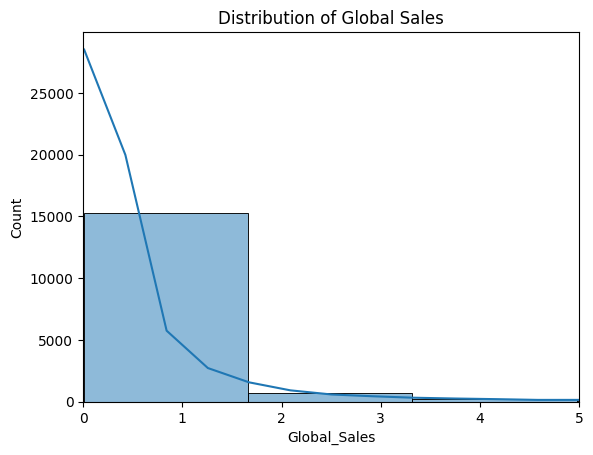

In [32]:
#Q-If we plot the distribution of global sales for all games, does it follow a Normal distribution or a Power Law (Long-Tail) distribution?
sns.histplot(df['Global_Sales'],bins=50,kde=True)
plt.xlim(0,5)
plt.title("Distribution of Global Sales")
plt.show()

In [33]:
##It follows long tail distribution

In [34]:
#Q-What is the 90th percentile threshold for global sales? (How many copies must a game sell to be in the top 10% of the industry?)
Q9=df['Global_Sales'].quantile(0.9)
print("90th percentile is:",Q9)
print(Q9,"M copies are to be sold.")

90th percentile is: 1.2139999999999964
1.2139999999999964 M copies are to be sold.


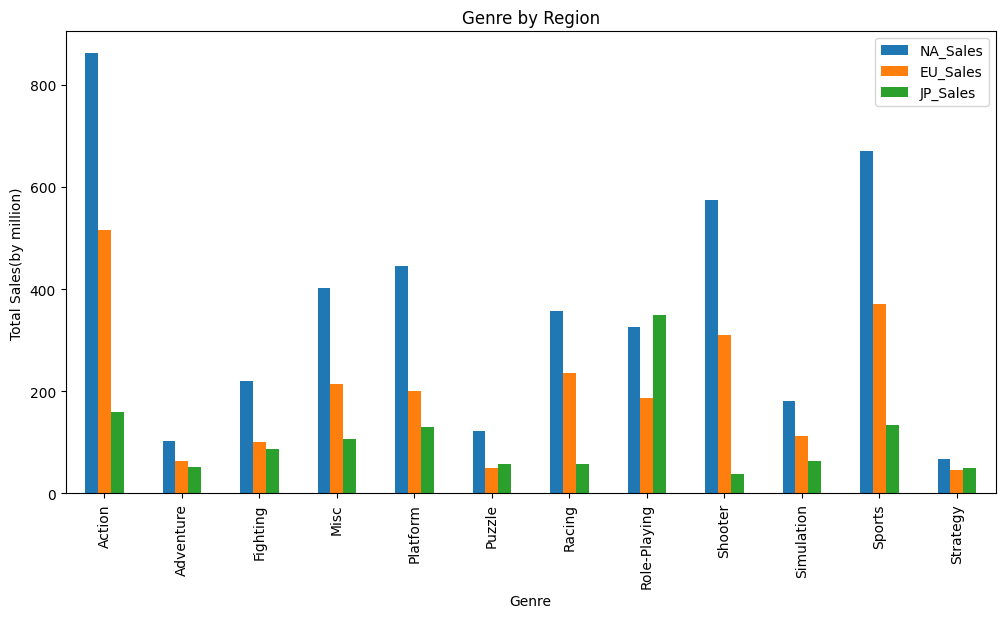

In [35]:
#Q-Which specific video game genre dominates the Japanese market but performs poorly in Western markets?
region=df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales']].sum()
region.plot(kind='bar',figsize=(12,6))
plt.title("Genre by Region")
plt.ylabel("Total Sales(by million)")
plt.show()
#correlation_matrix = region.corr()
#print("Correlation Matrix:")
#print(correlation_matrix)

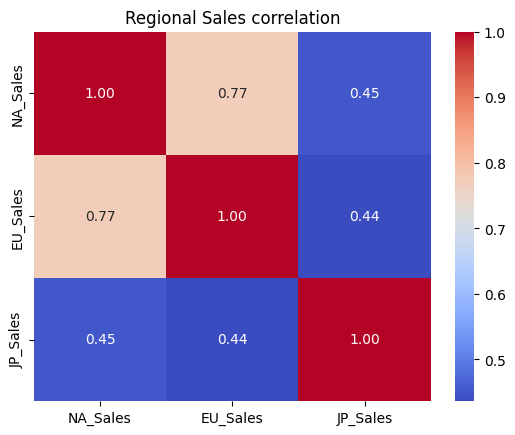

In [36]:
#Q-What is the exact mathematical correlation matrix between North American, European, and Japanese sales?
cor=df[['NA_Sales','EU_Sales','JP_Sales']].corr()
sns.heatmap(cor,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Regional Sales correlation")
plt.show()

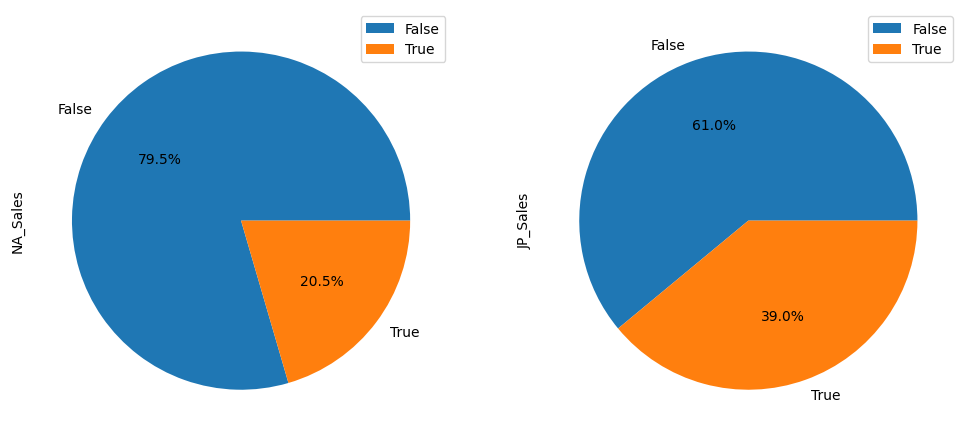

In [37]:
#Q-How does the market share of handheld consoles (like the Game Boy or Nintendo DS) compare in Japan versus North America?
handhelds = ['GB', 'GBA', 'DS', '3DS', 'PSP', 'PSV']
df['Is_Handheld'] = df['Platform'].isin(handhelds)
handhelds_share=df.groupby('Is_Handheld')[['NA_Sales','JP_Sales']].sum()
handhelds_share.plot(kind='pie', subplots=True, autopct='%1.1f%%', figsize=(12, 6))
plt.show()

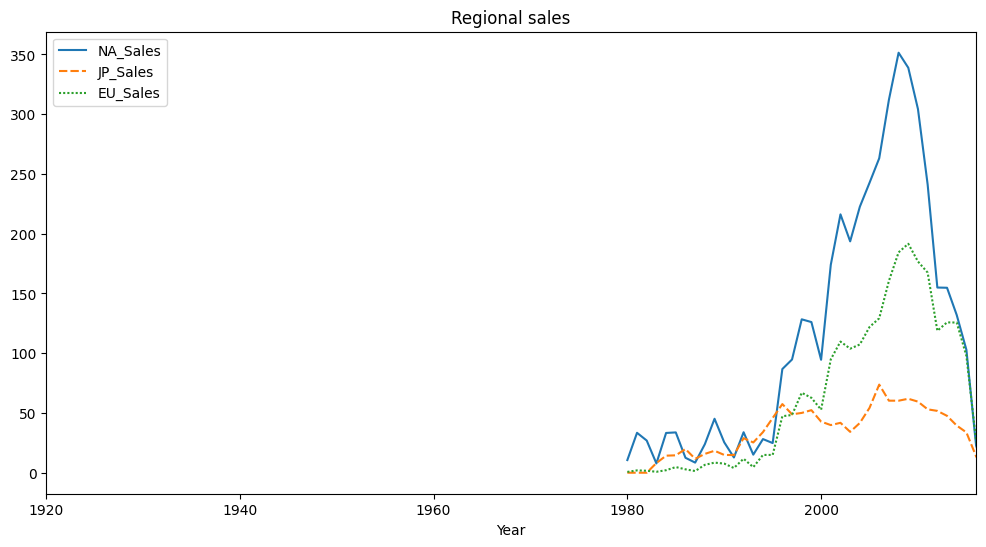

In [38]:
#Q-If we create a line plot of regional sales over time, which region's market peaked first, and which region held onto retail sales the longest?
yearly=df.groupby('Year')[['NA_Sales','JP_Sales','EU_Sales']].sum()
plt.figure(figsize=(12,6))
sns.lineplot(data=yearly)
plt.title('Regional sales')
plt.xlim(1920,2016)
plt.show()

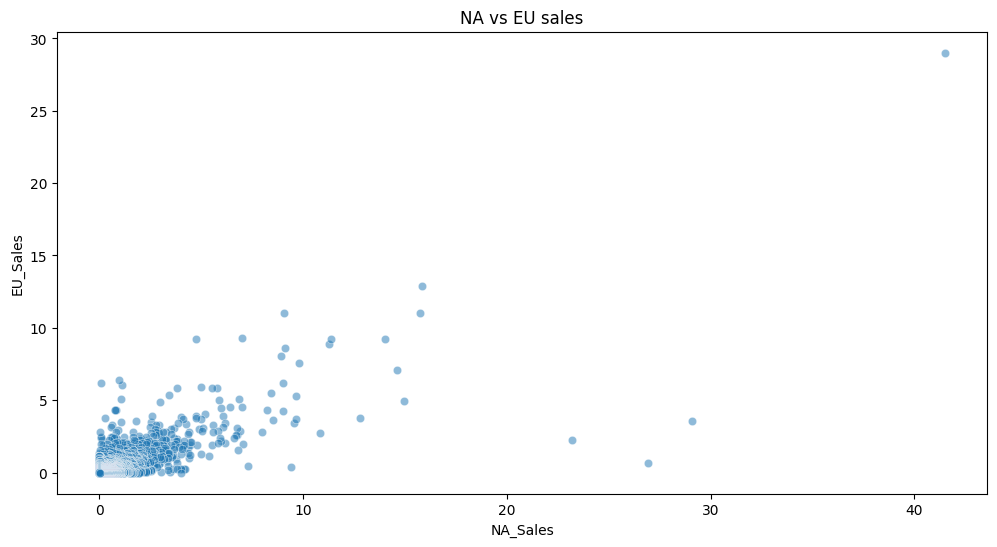

In [39]:
#Q-Visually, what does a scatter plot reveal about the relationship between European sales and North American sales per game?
plt.figure(figsize=(12,6))
sns.scatterplot(x='NA_Sales',y='EU_Sales',data=df,alpha=0.5)
plt.title("NA vs EU sales")
plt.show()

In [40]:
#Q-Feature: Western_Sales (NA + EU) — What percentage of global video game revenue is completely driven by the Western market?
df['Western_Sales']=df['EU_Sales']+df['NA_Sales']
total_western=df['Western_Sales'].sum()
total_global=df['Global_Sales'].sum()
print("Western Market:",(total_western/total_global)*100,"% of world")

Western Market: 76.4430250012471 % of world


In [41]:
#Q-Feature: Era (Retro vs. Modern vs. Current) — How has the average global revenue per individual title changed as the industry transitioned across these eras?
def assign_era(year):
    if year<=2000:return 'Retro Era'
    if year>2000 & year<=2010: return 'Modern Era'
    if year>2010:return 'Current Era' 
df['Era'] = df['Year'].apply(assign_era)
print(df.groupby('Era')['Global_Sales'].mean())

Era
Modern Era    0.497237
Retro Era     0.799419
Name: Global_Sales, dtype: float64


In [42]:
#Q-Feature: Sales_Concentration (Regional Sales / Global Sales) — Can we categorize games into "Regional Exclusives" versus "Global Blockbusters" based on where they made 80%+ of their money?
df['JP_conc']=df['JP_Sales']/df['Global_Sales']
def market_type(row):
    if row['JP_conc']>0.7:
        return 'Japan Exclusive Target'
    elif (row['NA_Sales']+row['EU_Sales'])/row['Global_Sales']>0.8:
        return 'Western Exclusive Focus'
    else:
        return 'Global Balanced'
df['Market_Strategy']=df.apply(market_type,axis=1)
print(df['Market_Strategy'].value_counts())

Market_Strategy
Western Exclusive Focus    10144
Japan Exclusive Target      3500
Global Balanced             2683
Name: count, dtype: int64


In [43]:
#Q-Feature: Is_Flagship_Console (Sony vs. Microsoft vs. Nintendo vs. Other) — Which parent console company has historical dominance
#over total global software revenue?
print(df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False))

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
GB       254.42
XB       252.09
NES      251.07
3DS      246.28
N64      218.21
SNES     200.05
GC       197.14
XOne     141.06
2600      86.57
WiiU      81.86
PSV       61.63
SAT       33.59
GEN       28.36
DC        15.97
SCD        1.87
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: Global_Sales, dtype: float64


In [44]:
#According to the report,we can conclude PS2 has higher dominance over total global software revenue.

In [45]:
#Q- Feature: Title_Length (Character count of game names) — Is there any statistical correlation between how long or short
#a game's title is and its final sales performance?
df['Title_Length']=df['Name'].apply(lambda x:len(str(x)))
correlation=df['Title_Length'].corr(df['Global_Sales'])
print("The correlation is:",correlation)

The correlation is: -0.07029447795685417


In [46]:
#Since the value is close to 0 indicates no relation between title length and market performance

In [ ]:
##**Conclusion:**  
#**Data-driven recommendation:**  
# **Target the Western market for scale as NA and EU covers over 70% of global revenue.  
  **Developing 'Shooting' or 'Action' game minimises entry level barrier resistance.  
  **Sony and Microsoft consoles yields highest software attachment rates per title.  
  **Budgeting should account for median performance baselines, rather than counting on matching mean revenue levels. 

## 🏁 Conclusion & Strategic Recommendations

### 📊 Data-Driven Market Insights:
* **Target the Western market for scale:** <br>&nbsp;&nbsp;&nbsp;&nbsp;Historical data shows that North America (NA) and Europe (EU) combined account for over 70% of total global video game revenue.
* **Prioritize high-demand genres:** <br>&nbsp;&nbsp;&nbsp;&nbsp;Developing 'Shooter' or 'Action' titles minimizes entry-level barrier resistance, as these categories consistently demonstrate the highest player adoption rates.
* **Deploy on dominant ecosystems:** <br>&nbsp;&nbsp;&nbsp;&nbsp;Sony (PlayStation) and Microsoft (Xbox) console families yield the highest software attachment rates per individual title.
* **Account for outlier dynamics in budgeting:** <br>&nbsp;&nbsp;&nbsp;&nbsp;Because the gaming market follows a long-tail distribution driven by rare blockbusters, financial planning should be anchored to median performance baselines rather than relying on average (mean) revenue projections.